<a href="https://colab.research.google.com/github/RosalynSolano/Trabajo-1-/blob/main/Tarea_Mate_grupal_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch

# Una entrada moderadamente grande (zona de saturación)
entrada = torch.tensor(8.0, requires_grad=True)

# Composición de 5 sigmoides
y = entrada

for _ in range(5):
    y = torch.sigmoid(y)

y.backward()

print(f"Gradiente acumulado tras 5 sigmoides: {entrada.grad.item():.6e}")

# Comparar con ReLU
entrada_relu = torch.tensor(8.0, requires_grad=True)

y = entrada_relu

for _ in range(5):
    y = torch.relu(y)

y.backward()

print(f"Gradiente acumulado tras 5 ReLUs: {entrada_relu.grad.item():.6e}")

Gradiente acumulado tras 5 sigmoides: 7.255669e-07
Gradiente acumulado tras 5 ReLUs: 1.000000e+00


Valor de equilibrio estimado (asíntota): 3.667 %
Coeficiente b: 3.099, tasa de decaimiento k: 0.0888


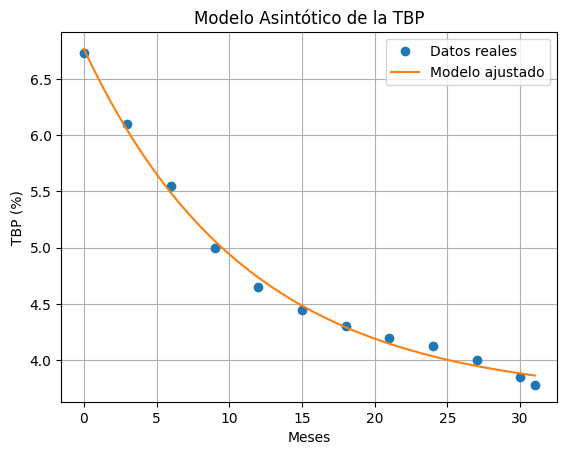

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Meses desde mayo 2023 (t=0)
t = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 31])

# Observaciones representativas de la TBP
tbp = np.array([6.73, 6.10, 5.55, 5.00, 4.65, 4.45,
                4.30, 4.20, 4.13, 4.00, 3.85, 3.78])

# Modelo: a + b * exp(-k*t)
# a = asíntota horizontal
def modelo_asintotico(t, a, b, k):
    return a + b * np.exp(-k * t)

# Ajuste del modelo
popt, _ = curve_fit(modelo_asintotico, t, tbp, p0=[3.0, 4.0, 0.1])

a_lim, b, k = popt

print(f"Valor de equilibrio estimado (asíntota): {a_lim:.3f} %")
print(f"Coeficiente b: {b:.3f}, tasa de decaimiento k: {k:.4f}")

# Graficar
t_suave = np.linspace(0, 31, 200)
tbp_modelo = modelo_asintotico(t_suave, a_lim, b, k)

plt.plot(t, tbp, 'o', label='Datos reales')
plt.plot(t_suave, tbp_modelo, label='Modelo ajustado')

plt.xlabel("Meses")
plt.ylabel("TBP (%)")
plt.title("Modelo Asintótico de la TBP")
plt.legend()
plt.grid(True)

plt.show()

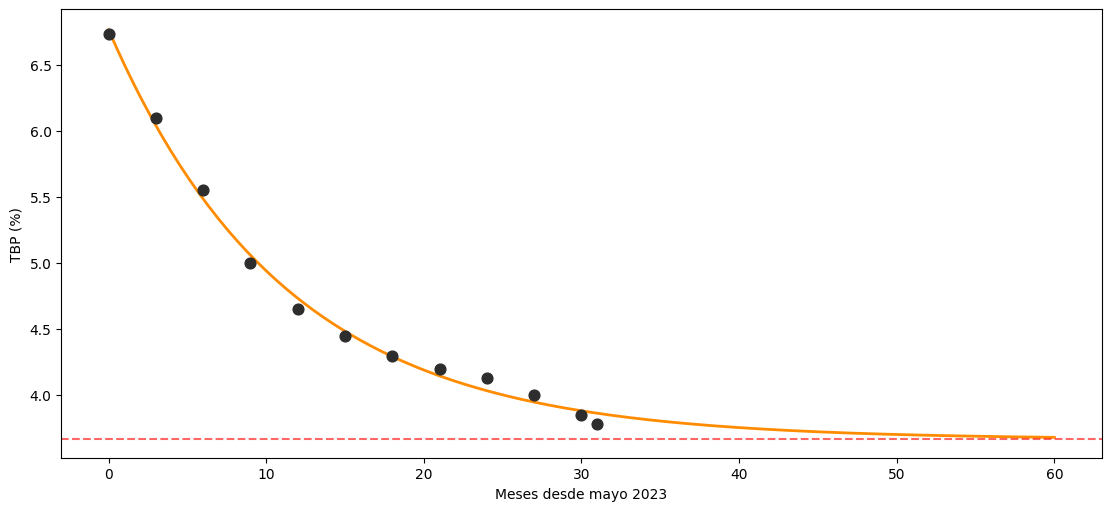

In [9]:
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')

# Datos reales
ax.scatter(
    t,
    tbp,
    color='#2D2D2D',
    s=60,
    zorder=3,
    label='TBP observada\n(BCCR)'
)

# Modelo ajustado
t_extend = np.linspace(0, 60, 200)

ax.plot(
    t_extend,
    modelo_asintotico(t_extend, *popt),
    color='#FF8C00',
    lw=2,
    label=f'Modelo: {a_lim:.2f} + {b:.2f}·exp(-{k:.3f}·t)'
)

# Asíntota horizontal
ax.axhline(
    a_lim,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Asíntota horizontal: y = {a_lim:.2f}%'
)

ax.set_xlabel('Meses desde mayo 2023')
ax.set_ylabel('TBP (%)')

plt.show()

In [10]:
import sympy as sp
t_sym, a_sym, b_sym, k_sym = sp.symbols('t a b k', real=True, positive=True)
modelo_sym = a_sym + b_sym * sp.exp(-k_sym * t_sym)
# Limite cuando t tiende a infinito
limite_infinito = sp.limit(modelo_sym, t_sym, sp.oo)
print(f"Limite simbolico cuando t-> oo: {limite_infinito}")
# Sustituyendo los valores estimados
print(f"Numericamente: {float(limite_infinito.subs([(a_sym, a_lim), (b_sym,
b), (k_sym, k)]))}")

Limite simbolico cuando t-> oo: a
Numericamente: 3.666683575219184
